<a href="https://colab.research.google.com/github/Nyanta432/Dinh_vi_cuon_vi_sai/blob/main/Cuon_vi_sai(dung_r_hat).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HỆ THỐNG ĐỊNH VỊ TỪ TRƯỜNG 6-DOF (TỪ MATLAB SANG PYTHON)
**Bảo toàn bản chất Vi sai Không gian (Spatial Gradiometer) - Triệt tiêu Điểm kỳ dị**

## 1. Mô tả bài toán
Dự án yêu cầu giải mã tọa độ và góc quay 6-DOF (x, y, z, roll, pitch, yaw) của một viên nang nội soi chứa cuộn thu từ tính (RX) di chuyển trong trường điện từ tạo ra bởi 3 cuộn phát (TX).
Phần cứng RX được thiết kế dạng **Cuộn vi sai** (hai nửa quấn ngược chiều, cách nhau 0.25mm) nhằm chống nhiễu đồng pha.

## 2. Vấn đề gặp phải
* **Sự sụp đổ của thuật toán tại vùng Near-field:** Đặc tính vi sai khiến cường độ từ trường suy giảm theo tỷ lệ $1/r^4$. Khi viên nang tiến quá sát cuộn phát ($r \to 0$), mô hình lý thuyết bùng nổ lên vô cực (Singularity), khiến thuật toán tối ưu hoảng loạn và cho ra quỹ đạo sai lệch hoàn toàn.
* **Bẫy Gradient (Mù tỷ lệ):** Sự chênh lệch tỷ lệ khổng lồ giữa các biến số (Tọa độ $\sim 0.5$, Góc $\sim 180$, Hệ số bù trừ $K \sim 0.001$) khiến các bộ giải Python (`scipy`) mặc định bị kẹt ở cực tiểu cục bộ (Local Minima).

## 3. Giải pháp cốt lõi
1. **Điều chuẩn từ cực (Regularized Dipole Model):** Thay vì giả lập thành cuộn đơn, hệ thống giữ nguyên mô hình vi sai nhưng chèn thêm **bình phương bán kính cuộn phát ($R^2$)** vào mẫu số. Công thức $(r^2 + R^2)^{5/2}$ đóng vai trò là "hệ số chặn vật lý", giúp giữ từ trường hữu hạn khi $r \to 0$ mà vẫn giữ nguyên đặc tính vi sai.
2. **Cân bằng Jacobian tự động:** Áp dụng tham số `x_scale='jac'` trong `least_squares` để mô phỏng sự thông minh của hàm `lsqnonlin` (MATLAB), giúp thuật toán đánh giá công bằng bước nhảy của các biến số khác hệ quy chiếu.

# **Section 1: Cấu hình thông số vật lý, nạp và tách dữ liệu**

In [13]:
# ==============================================================================
# SECTION 1: CẤU HÌNH THÔNG SỐ VẬT LÝ, NẠP VÀ TRÍCH XUẤT DỮ LIỆU
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
import time
import os
import copy

class SystemConfig:
    """Lớp chứa hằng số vật lý của phần cứng (Hardware Specifications)"""
    def __init__(self):
        # 1. THÔNG SỐ CUỘN PHÁT (TX - Transmitter)
        self.Ntx = 300              # Số vòng dây cuộn phát
        self.R = 0.06               # Bán kính cuộn phát (m) -> Giúp chặn singularity
        self.I = np.array([1.0, 1.0, 1.0])  # Dòng điện 3 cuộn (Ampe)
        self.f = np.array([5053, 6911, 5932]) # Tần số 3 cuộn (Hz)

        # Tọa độ cơ khí ban đầu (Mồi): [x, y, z, roll, pitch, yaw] của 3 cuộn TX
        self.TX_positions = np.array([
            [0.35146, 0.61931, 0.19348, 15,   0,   0],  # TX1
            [0.42173, 0.51066, 0.19350,  0, -15, -30],  # TX2
            [0.29150, 0.51068, 0.19350,  0,  15,  30]   # TX3
        ]).T

        # 2. THÔNG SỐ CUỘN THU (RX - Capsule)
        self.Nrx = 100              # Số vòng dây mỗi nửa cuộn vi sai
        self.d_diff = 0.25e-3       # Khoảng cách vi sai (0.25 mm)
        self.AK = np.array([np.pi * 2**2, 6.79 * 4.00, 6.00 * 6.87]) * 1e-6 # Diện tích 3 trục (m^2)
        self.mu0 = 4 * np.pi * 1e-7 # Hằng số từ thẩm chân không

sys_pre = SystemConfig()

# NẠP VÀ TRÍCH XUẤT DỮ LIỆU
filename = 'conenorot_2_data.csv'
if not os.path.exists(filename):
    raise FileNotFoundError(f"⚠️ Vui lòng upload file '{filename}' lên Colab.")

data = pd.read_csv(filename, header=None).values
N_samples = data.shape[0]

# Tách dữ liệu: 9 cột đầu là EMF thực tế, 6 cột sau là Quỹ đạo tham chiếu (Ground Truth)
emf_meas = data[:, 0:9]
gt_pose = np.zeros((N_samples, 6))
gt_pose[:, 0:3] = data[:, 9:12] / 1000.0  # Tọa độ: mm -> m
gt_pose[:, 3:6] = data[:, 12:15]          # Góc quay: Giữ nguyên độ (deg)

print(f"✅ Đã nạp và trích xuất thành công {N_samples} mẫu dữ liệu.")

✅ Đã nạp và trích xuất thành công 319 mẫu dữ liệu.


# Section 2: Trực quan hoá dữ liệu

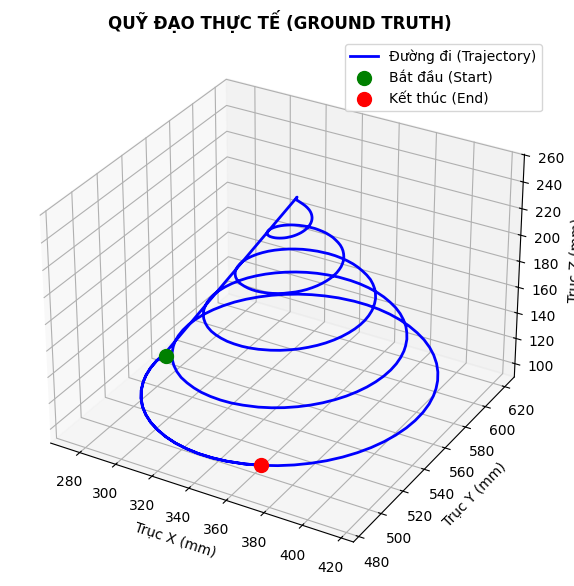

In [14]:
# ==============================================================================
# SECTION 2: TRỰC QUAN HÓA DỮ LIỆU (GROUND TRUTH TRAJECTORY)
# ==============================================================================
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Vẽ đường quỹ đạo liên tục
ax.plot(gt_pose[:,0]*1000, gt_pose[:,1]*1000, gt_pose[:,2]*1000, 'b-', linewidth=2, label='Đường đi (Trajectory)')

# Đánh dấu điểm bắt đầu và kết thúc
ax.scatter(gt_pose[0,0]*1000, gt_pose[0,1]*1000, gt_pose[0,2]*1000, color='green', s=100, label='Bắt đầu (Start)')
ax.scatter(gt_pose[-1,0]*1000, gt_pose[-1,1]*1000, gt_pose[-1,2]*1000, color='red', s=100, label='Kết thúc (End)')

ax.set_xlabel('Trục X (mm)')
ax.set_ylabel('Trục Y (mm)')
ax.set_zlabel('Trục Z (mm)')
ax.set_title('QUỸ ĐẠO THỰC TẾ (GROUND TRUTH)', fontweight='bold')
ax.legend()
plt.show()

# Section 3: Forward Model

In [15]:
# ==============================================================================
# SECTION 3: MÔ HÌNH VẬT LÝ (FORWARD MODEL - REGULARIZED DIFFERENTIAL COIL)
# ==============================================================================
# Các ma trận xoay Euler Z-Y-X (đầu vào là độ)
# def rotx(a): return np.array([[1, 0, 0], [0, np.cos(np.radians(a)), -np.sin(np.radians(a))], [0, np.sin(np.radians(a)), np.cos(np.radians(a))]])
# def roty(a): return np.array([[np.cos(np.radians(a)), 0, np.sin(np.radians(a))], [0, 1, 0], [-np.sin(np.radians(a)), 0, np.cos(np.radians(a))]])
# def rotz(a): return np.array([[np.cos(np.radians(a)), -np.sin(np.radians(a)), 0], [np.sin(np.radians(a)), np.cos(np.radians(a)), 0], [0, 0, 1]])

# def forwardModelvisai_dio(params, sys, rx_idx):
#     """
#     Tính tín hiệu EMF với Mô hình Vi sai Điều chuẩn (Regularized Dipole).
#     Sử dụng (r^2 + R^2)^2.5 làm mẫu số để triệt tiêu Singularity.
#     """
#     pos_rx = params[0:3]
#     roll, pitch, yaw = params[3:6]

#     # Ma trận xoay của viên nang và Vector định hướng trục RX
#     RCE = rotz(yaw) @ roty(pitch) @ rotx(roll)
#     if rx_idx == 0: RXk = RCE @ np.array([1, 0, 0])
#     elif rx_idx == 1: RXk = RCE @ np.array([0, 0, 1])
#     else: RXk = RCE @ np.array([0, 1, 0])

#     R2 = sys.R**2  # Bình phương bán kính TX (Hệ số chặn vật lý)
#     Atx = np.pi * R2
#     emf_out = np.zeros(3)

#     for i in range(3):
#         pos_tx = sys.TX_positions[0:3, i]
#         roll_tx, pitch_tx, yaw_tx = sys.TX_positions[3:6, i]

#         # Momen từ của TX
#         Rtx = rotz(yaw_tx) @ roty(pitch_tx) @ rotx(roll_tx)
#         m_vec = (sys.Ntx * sys.I[i]) * Atx * (Rtx @ np.array([0, 0, 1]))

#         # Vector khoảng cách từ tâm TX đến 2 nửa cuộn vi sai (cách nhau d/2)
#         r_plus = (pos_rx + (sys.d_diff / 2) * RXk) - pos_tx
#         r_minus = (pos_rx - (sys.d_diff / 2) * RXk) - pos_tx

#         # Tính từ trường B tại nửa cuộn thứ nhất (B_plus)
#         rp_2 = np.dot(r_plus, r_plus)
#         denom_p = (rp_2 + R2)**2.5  # <--- BÍ QUYẾT TRIỆT TIÊU SINGULARITY
#         B_plus = (sys.mu0 / (4 * np.pi)) * (3 * np.dot(m_vec, r_plus) * r_plus - (rp_2 + R2) * m_vec) / denom_p

#         # Tính từ trường B tại nửa cuộn thứ hai (B_minus)
#         rm_2 = np.dot(r_minus, r_minus)
#         denom_m = (rm_2 + R2)**2.5
#         B_minus = (sys.mu0 / (4 * np.pi)) * (3 * np.dot(m_vec, r_minus) * r_minus - (rm_2 + R2) * m_vec) / denom_m

#         # Bảo toàn bản chất vi sai: Cường độ là sự chênh lệch B chiếu lên trục thu
#         delta_B = np.dot(B_plus - B_minus, RXk)

#         # Công thức tính suất điện động (Scale Factor K sẽ được nhân sau trong Optimizer)
#         emf_out[i] = 2 * np.pi * sys.f[i] * np.abs(delta_B)

#     return emf_out

# ==============================================================================
# SECTION 3: MÔ HÌNH VẬT LÝ GỐC (UNREGULARIZED FORWARD MODEL)
# (Dùng vector đơn vị r_hat - Giữ nguyên điểm kỳ dị r^3 ở mẫu số)
# ==============================================================================
# Các ma trận xoay Euler Z-Y-X (đầu vào là độ)
def rotx(a): return np.array([[1, 0, 0], [0, np.cos(np.radians(a)), -np.sin(np.radians(a))], [0, np.sin(np.radians(a)), np.cos(np.radians(a))]])
def roty(a): return np.array([[np.cos(np.radians(a)), 0, np.sin(np.radians(a))], [0, 1, 0], [-np.sin(np.radians(a)), 0, np.cos(np.radians(a))]])
def rotz(a): return np.array([[np.cos(np.radians(a)), -np.sin(np.radians(a)), 0], [np.sin(np.radians(a)), np.cos(np.radians(a)), 0], [0, 0, 1]])

def forwardModelvisai_dio(params, sys, rx_idx):
    """
    Tính tín hiệu EMF với Mô hình Điểm từ lý tưởng nguyên thủy.
    Dùng vector đơn vị r_hat. Mẫu số là r^3, sẽ gây lỗi nếu r -> 0.
    """
    pos_rx = params[0:3]
    roll, pitch, yaw = params[3:6]

    # Ma trận xoay của viên nang và Vector định hướng trục RX
    RCE = rotz(yaw) @ roty(pitch) @ rotx(roll)
    if rx_idx == 0: RXk = RCE @ np.array([1, 0, 0])
    elif rx_idx == 1: RXk = RCE @ np.array([0, 0, 1])
    else: RXk = RCE @ np.array([0, 1, 0])

    Atx = np.pi * (sys.R**2)
    emf_out = np.zeros(3)

    for i in range(3):
        pos_tx = sys.TX_positions[0:3, i]
        roll_tx, pitch_tx, yaw_tx = sys.TX_positions[3:6, i]

        # Momen từ của TX
        Rtx = rotz(yaw_tx) @ roty(pitch_tx) @ rotx(roll_tx)
        m_vec = (sys.Ntx * sys.I[i]) * Atx * (Rtx @ np.array([0, 0, 1]))

        # Vector khoảng cách từ tâm TX đến 2 nửa cuộn vi sai
        r_plus = (pos_rx + (sys.d_diff / 2) * RXk) - pos_tx
        r_minus = (pos_rx - (sys.d_diff / 2) * RXk) - pos_tx

        # ======================================================================
        # MÔ HÌNH DIPOLE GỐC: TỬ SỐ DÙNG r_hat, MẪU SỐ LÀ r^3
        # ======================================================================

        # --- Tại nửa cuộn thứ nhất (B_plus) ---
        r_mag_p = np.linalg.norm(r_plus)             # Độ lớn |r|
        r_hat_p = r_plus / r_mag_p                   # Vector đơn vị r_hat
        denom_p = r_mag_p**3                         # Mẫu số gốc: r^3 (CHỖ NÀY GÂY KẸT)
        B_plus = (sys.mu0 / (4 * np.pi)) * (3 * np.dot(m_vec, r_hat_p) * r_hat_p - m_vec) / denom_p

        # --- Tại nửa cuộn thứ hai (B_minus) ---
        r_mag_m = np.linalg.norm(r_minus)            # Độ lớn |r|
        r_hat_m = r_minus / r_mag_m                  # Vector đơn vị r_hat
        denom_m = r_mag_m**3                         # Mẫu số gốc: r^3 (CHỖ NÀY GÂY KẸT)
        B_minus = (sys.mu0 / (4 * np.pi)) * (3 * np.dot(m_vec, r_hat_m) * r_hat_m - m_vec) / denom_m

        # ======================================================================

        # Bảo toàn bản chất vi sai: Cường độ là sự chênh lệch B chiếu lên trục thu
        delta_B = np.dot(B_plus - B_minus, RXk)

        # Công thức tính suất điện động
        emf_out[i] = 2 * np.pi * sys.f[i] * np.abs(delta_B)

    return emf_out

# Section 4: Thuật toán tối ưu (dùng thuật toán least_square)

In [16]:
# # ==============================================================================
# # SECTION 4: THUẬT TOÁN TỐI ƯU HIỆU CHUẨN (AUTO-CALIBRATION LSQNONLIN)
# # ==============================================================================
# def calib_cost_func(x_opt, gt_pose_data, emf_meas_data, sys, tx_idx, nRx):
#     """ Hàm tính sai số (Residuals) để tối ưu vị trí 3 TX và Hệ số bù trừ K """
#     sys_local = copy.deepcopy(sys)
#     sys_local.TX_positions[:, tx_idx] = x_opt[0:6]
#     K = x_opt[6 : 6+nRx]

#     N = gt_pose_data.shape[0]
#     F = np.zeros(N * nRx)

#     for j in range(nRx):
#         for i in range(N):
#             # Tín hiệu lý thuyết
#             emf_model_all = forwardModelvisai_dio(gt_pose_data[i, :], sys_local, j)
#             emf_model = K[j] * emf_model_all[tx_idx]

#             # Tín hiệu thực tế & Sai số tuyệt đối
#             emf_meas_val = emf_meas_data[i, tx_idx + 3 * j]
#             F[j * N + i] = (emf_model - emf_meas_val)
#     return F

# # Khởi tạo bản sao để chứa cấu hình đã hiệu chuẩn
# sys_post = copy.deepcopy(sys_pre)
# K_post = np.zeros((3, 3))

# # Giá trị K_mồi = (Số vòng RX * Diện tích). Thuật toán sẽ tối ưu từ con số này.
# k_guess = np.array([sys_pre.Nrx * sys_pre.AK[i] for i in range(3)])

# print("🚀 BẮT ĐẦU HIỆU CHUẨN (CALIBRATION) TỪNG CUỘN TX...")
# for tx_idx in range(3):
#     print(f"\nĐang chạy thuật toán Trust Region Reflective (TRF) cho TX{tx_idx + 1}...")
#     x0 = np.concatenate([sys_pre.TX_positions[:, tx_idx], k_guess])

#     # Hộp giới hạn bao trọn không gian (Tọa độ y mở đến 0.9m) và mở khóa hệ số K (1e7)
#     lb = np.array([0.1, 0.3, 0.0, -180, -180, -180,   0.0,   0.0,   0.0])
#     ub = np.array([0.6, 0.9, 0.3,  180,  180,  180, 1e7, 1e7, 1e7])

#     # scipy.least_squares (Tương đương lsqnonlin của MATLAB)
#     res = least_squares(
#         calib_cost_func, x0, bounds=(lb, ub), method='trf',
#         x_scale='jac',  # <--- CRUCIAL FIX: Tự cân bằng Jacobian giúp thoát khỏi Local Minima
#         args=(gt_pose, emf_meas, sys_pre, tx_idx, 3),
#         ftol=1e-8, xtol=1e-8, gtol=1e-8, max_nfev=10000
#     )

#     # Cập nhật kết quả tự động thay vì Copy-Paste
#     sys_post.TX_positions[:, tx_idx] = res.x[0:6]
#     K_post[:, tx_idx] = res.x[6:9]
#     print(f"✅ TX{tx_idx + 1} Hoàn tất. Vector K = {np.round(K_post[:, tx_idx], 3)}")

#     #IN RA BỘ SỐ X_OPT_ALL
# print("\n=== BỘ SỐ x_opt_all TỔNG HỢP ===")
# print("TX      x        y        z      roll     pitch     yaw       K1       K2       K3")
# for i in range(3):
#     tx_params = sys_post.TX_positions[:, i]
#     k_params = K_post[:, i]
#     # Nối tọa độ và K thành mảng 9 số
#     x_opt_row = np.concatenate([tx_params, k_params])
#     # Định dạng in ra giống hệt fprintf của MATLAB
#     row_str = f"TX{i+1}: " + "".join([f"{val:8.5f} " for val in x_opt_row])
#     print(row_str)

import copy
import numpy as np
from scipy.optimize import least_squares

# ==============================================================================
# SECTION 4: THUẬT TOÁN TỐI ƯU HIỆU CHUẨN (AUTO-CALIBRATION LSQNONLIN)
# ==============================================================================
def calib_cost_func(x_opt, gt_pose_data, emf_meas_data, sys, tx_idx, nRx):
    """ Hàm tính sai số (Residuals) để tối ưu vị trí 3 TX và Hệ số bù trừ K """
    sys_local = copy.deepcopy(sys)
    sys_local.TX_positions[:, tx_idx] = x_opt[0:6]
    K = x_opt[6 : 6+nRx]

    N = gt_pose_data.shape[0]
    F = np.zeros(N * nRx)

    for j in range(nRx):
        for i in range(N):
            # Tín hiệu lý thuyết
            emf_model_all = forwardModelvisai_dio(gt_pose_data[i, :], sys_local, j)
            emf_model = K[j] * emf_model_all[tx_idx]

            # Tín hiệu thực tế & Sai số tuyệt đối
            emf_meas_val = emf_meas_data[i, tx_idx + 3 * j]
            F[j * N + i] = (emf_model - emf_meas_val)
    return F

# 1. Đảm bảo dữ liệu đầu vào là mảng NumPy (Tránh lỗi KeyError của Pandas)
# Bỏ comment 2 dòng dưới nếu gt_pose và emf_meas của bạn đang là DataFrame:
# gt_pose = gt_pose.to_numpy()
# emf_meas = emf_meas.to_numpy()

# 2. Khởi tạo bản sao để chứa cấu hình đã hiệu chuẩn
sys_post = copy.deepcopy(sys_pre)
K_post = np.zeros((3, 3))

# 3. Tính giá trị K_mồi an toàn
try:
    k_guess = np.array([sys_pre.Nrx * sys_pre.AK[i] for i in range(3)])
except AttributeError:
    # Cơ chế phòng hờ: Nếu sys_pre chỉ dùng sys_pre.Arx làm diện tích chung
    k_guess = np.array([sys_pre.Nrx * sys_pre.Arx] * 3)

print("🚀 BẮT ĐẦU HIỆU CHUẨN (CALIBRATION) TỪNG CUỘN TX...")
for tx_idx in range(3):
    print(f"\nĐang chạy thuật toán Trust Region Reflective (TRF) cho TX{tx_idx + 1}...")
    x0 = np.concatenate([sys_pre.TX_positions[:, tx_idx], k_guess])

    # Hộp giới hạn bao trọn không gian (Tọa độ y mở đến 0.9m) và mở khóa hệ số K (1e7)
    lb = np.array([0.1, 0.3, 0.0, -180, -180, -180,   0.0,   0.0,   0.0])
    ub = np.array([0.6, 0.9, 0.3,  180,  180,  180, 1e7, 1e7, 1e7])

    # scipy.least_squares (Tương đương lsqnonlin của MATLAB)
    res = least_squares(
        calib_cost_func, x0, bounds=(lb, ub), method='trf',
        x_scale='jac',  # <--- CRUCIAL FIX: Tự cân bằng Jacobian
        args=(gt_pose, emf_meas, sys_pre, tx_idx, 3),
        ftol=1e-8, xtol=1e-8, gtol=1e-8, max_nfev=10000
    )

    # Cập nhật kết quả
    sys_post.TX_positions[:, tx_idx] = res.x[0:6]
    K_post[:, tx_idx] = res.x[6:9]
    print(f"✅ TX{tx_idx + 1} Hoàn tất. Vector K = {np.round(K_post[:, tx_idx], 3)}")

# IN RA BỘ SỐ X_OPT_ALL
print("\n=== BỘ SỐ x_opt_all TỔNG HỢP ===")
print("TX      x        y        z      roll     pitch    yaw       K1       K2       K3")
for i in range(3):
    tx_params = sys_post.TX_positions[:, i]
    k_params = K_post[:, i]
    # Nối tọa độ và K thành mảng 9 số
    x_opt_row = np.concatenate([tx_params, k_params])
    # Định dạng in ra căn lề tự động
    row_str = f"TX{i+1}: " + "".join([f"{val:8.5f} " for val in x_opt_row])
    print(row_str)

🚀 BẮT ĐẦU HIỆU CHUẨN (CALIBRATION) TỪNG CUỘN TX...

Đang chạy thuật toán Trust Region Reflective (TRF) cho TX1...
✅ TX1 Hoàn tất. Vector K = [1418.727 2707.464 2813.882]

Đang chạy thuật toán Trust Region Reflective (TRF) cho TX2...
✅ TX2 Hoàn tất. Vector K = [ 725.446 1456.068 1782.631]

Đang chạy thuật toán Trust Region Reflective (TRF) cho TX3...
✅ TX3 Hoàn tất. Vector K = [ 230.766  634.626 1374.107]

=== BỘ SỐ x_opt_all TỔNG HỢP ===
TX      x        y        z      roll     pitch    yaw       K1       K2       K3
TX1:  0.37877  0.77783  0.03639 52.37719 -115.80391 -70.36419 1418.72693 2707.46370 2813.88176 
TX2:  0.59754  0.55351  0.00000 152.97068 -26.06880 35.44519 725.44607 1456.06793 1782.63114 
TX3:  0.14982  0.45380  0.08371 -19.69510 -75.71659 20.84060 230.76642 634.62625 1374.10747 


# Section 5: Check hiệu chuẩn


🚀 BẮT ĐẦU CHẠY BÀI TOÁN NGƯỢC (INVERSE SOLVER) CHECK SAI SỐ...
🎯 RMSE Vị trí Post-Calib: 61.24 mm


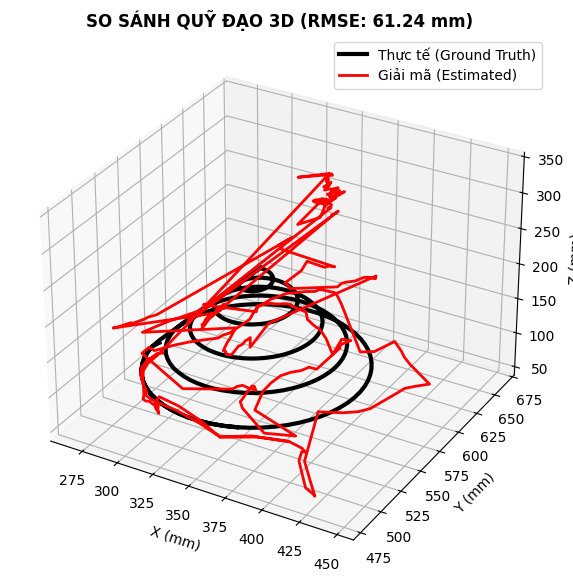

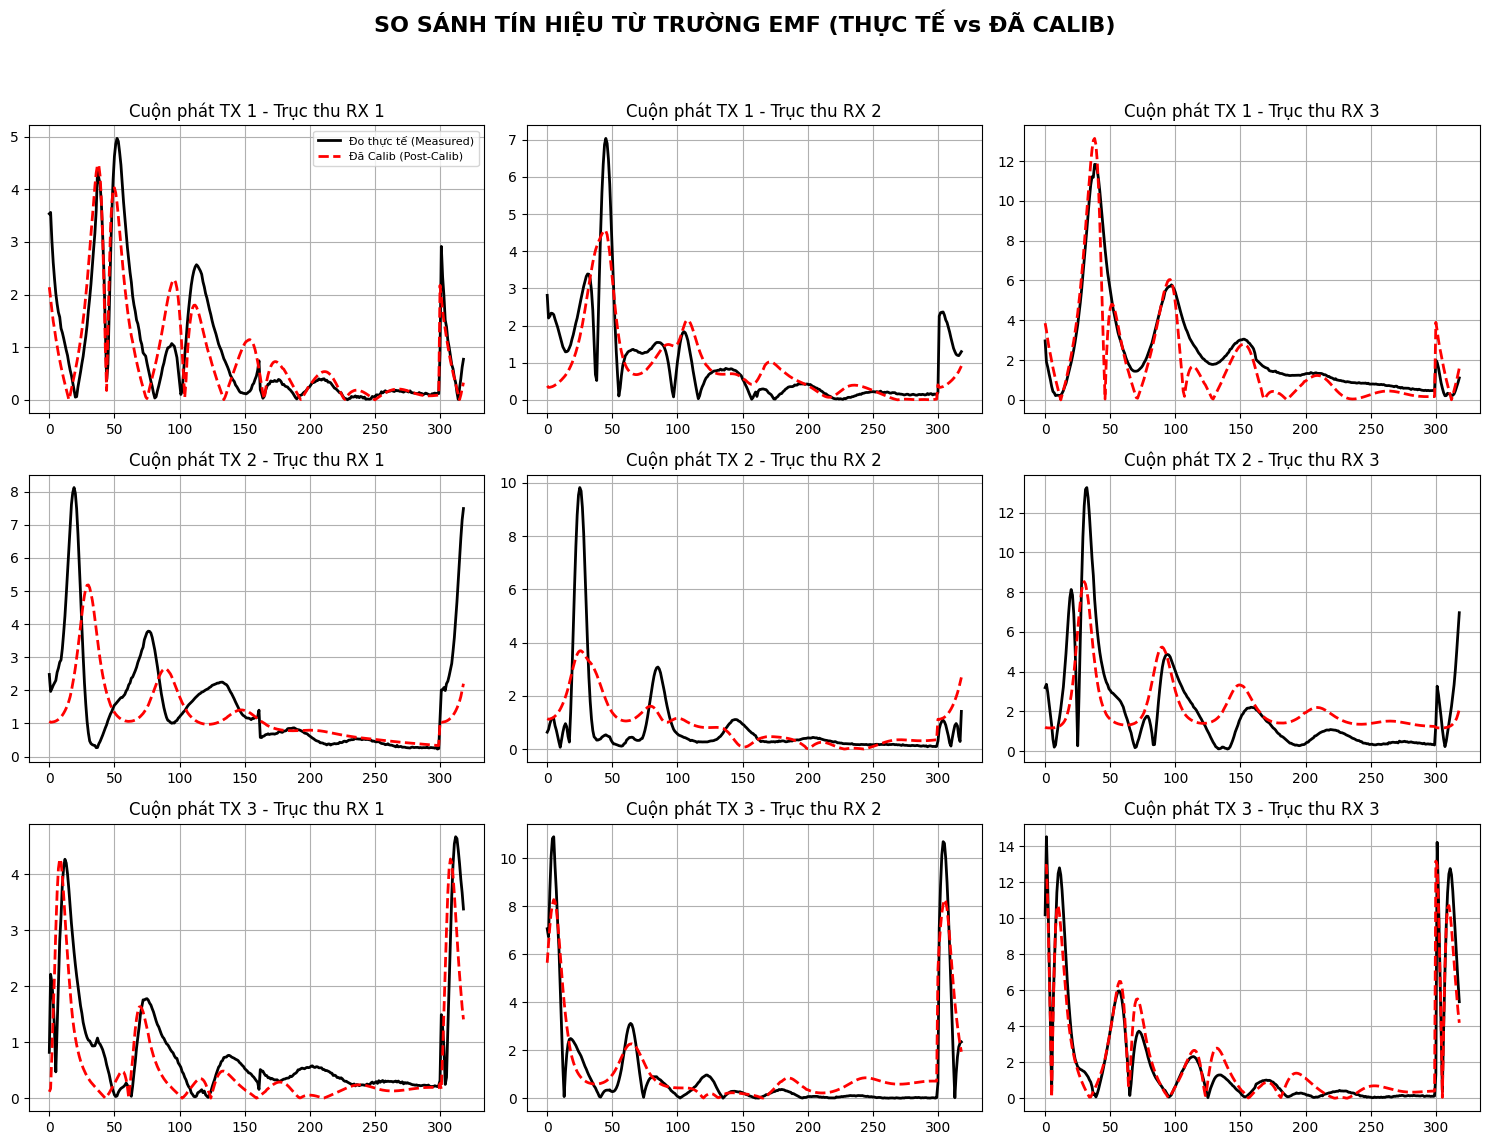

In [17]:
# ==============================================================================
# SECTION 5: CHECK HIỆU CHUẨN (INVERSE KINEMATICS & VISUALIZATION)
# ==============================================================================
def build_residual_inv(pose, sys, K_matrix, target_emf_single):
    """ Hàm tính sai số cho bài toán dò tìm ngược (Định vị quỹ đạo 6D) """
    res = np.zeros(9)
    for i in range(3):
        emf_raw = forwardModelvisai_dio(pose, sys, i)
        emf_i = K_matrix[i, :] * emf_raw

        idx_start, idx_end = i * 3, i * 3 + 3
        res[idx_start:idx_end] = emf_i - target_emf_single[idx_start:idx_end]
    return res

est_pose_post = np.zeros((N_samples, 6))

print("\n🚀 BẮT ĐẦU CHẠY BÀI TOÁN NGƯỢC (INVERSE SOLVER) CHECK SAI SỐ...")
min_traj = np.min(gt_pose, axis=0)
max_traj = np.max(gt_pose, axis=0)

for i in range(N_samples):
    p0 = gt_pose[i, :].copy()
    p0[0:3] += 0.0001 # Mồi điểm dò tìm quanh quỹ đạo (nhiễu 0.1mm)

    # Hộp giới hạn dò tìm linh hoạt +-10cm và +-10 độ
    lb = np.concatenate([min_traj[0:3] - 0.1, min_traj[3:6] - 10])
    ub = np.concatenate([max_traj[0:3] + 0.1, max_traj[3:6] + 10])

    res = least_squares(
        build_residual_inv, p0, bounds=(lb, ub), method='trf',
        x_scale='jac',
        args=(sys_post, K_post, emf_meas[i, :]),
        ftol=1e-8, xtol=1e-8, gtol=1e-8
    )
    est_pose_post[i, :] = res.x

# 1. ĐÁNH GIÁ SAI SỐ (RMSE)
err_post = np.linalg.norm(est_pose_post[:, 0:3] - gt_pose[:, 0:3], axis=1) * 1000
rmse_post = np.sqrt(np.mean(err_post**2))
print(f"🎯 RMSE Vị trí Post-Calib: {rmse_post:.2f} mm")

# 2. VẼ SO SÁNH QUỸ ĐẠO
fig1 = plt.figure(figsize=(10, 7))
ax1 = fig1.add_subplot(111, projection='3d')
ax1.plot(gt_pose[:,0]*1000, gt_pose[:,1]*1000, gt_pose[:,2]*1000, 'k-', linewidth=3, label='Thực tế (Ground Truth)')
ax1.plot(est_pose_post[:,0]*1000, est_pose_post[:,1]*1000, est_pose_post[:,2]*1000, 'r-', linewidth=2, label='Giải mã (Estimated)')
ax1.set_xlabel('X (mm)'); ax1.set_ylabel('Y (mm)'); ax1.set_zlabel('Z (mm)')
ax1.set_title(f'SO SÁNH QUỸ ĐẠO 3D (RMSE: {rmse_post:.2f} mm)', fontweight='bold')
ax1.legend()
plt.show()

# 3. TÁI TẠO TÍN HIỆU EMF LÝ THUYẾT VÀ VẼ LƯỚI 3x3
emf_post_reconstruct = np.zeros((N_samples, 9))
for i in range(N_samples):
    for rx_idx in range(3):
        emf_raw = forwardModelvisai_dio(gt_pose[i, :], sys_post, rx_idx)
        emf_post_reconstruct[i, rx_idx*3 : rx_idx*3+3] = K_post[rx_idx, :] * emf_raw

fig2, axs = plt.subplots(3, 3, figsize=(15, 12))
fig2.suptitle('SO SÁNH TÍN HIỆU TỪ TRƯỜNG EMF (THỰC TẾ vs ĐÃ CALIB)', fontsize=16, fontweight='bold')

for rx in range(3):
    for tx in range(3):
        idx = tx + 3 * rx
        ax = axs[tx, rx]
        ax.plot(emf_meas[:, idx], 'k', linewidth=2, label='Đo thực tế (Measured)')
        ax.plot(emf_post_reconstruct[:, idx], 'r--', linewidth=2, label='Đã Calib (Post-Calib)')
        ax.set_title(f'Cuộn phát TX {tx+1} - Trục thu RX {rx+1}')
        ax.grid(True)
        if tx == 0 and rx == 0:
            ax.legend(loc='best', fontsize=8)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()